In [786]:
from context import samplers as samplers

import numpy as np


def soft(x,tau): 
    return np.sign(x)*np.maximum(np.abs(x)-tau,0)


def make_prox_kernel(tau, grad, lam, gamma, p, beta=1):
    grad_F = lambda x:  grad(x) + (x - soft(x,lam*gamma))/gamma

    def step(z):
        return samplers.one_step_langevin(z, p, grad_F, tau,beta)
    return step

def make_hadamard_kernel(tau, grad, lam, p,beta=1):
    def step(z):
        return samplers.one_step_hadamard(z, p, grad, tau, lam,beta)
    return step

def project_hadamard(z, p):
    return z[:p] * z[p:]

# Visualize paths in 2D

In [994]:
import matplotlib.pyplot as plt

p = 2
lam = 2
tau = 0.01
beta= 1.

# smooth part: G(x) = 1/2 ||x||^2
grad = lambda x: x

A = np.array([[1.0, 0.0],
              [0.0, .1]])   # second direction weak
y = np.array([1.0, 1.0])


Lf = np.linalg.norm(A.T@A, 2)
gamma= 1/Lf/6
tau = gamma/5/(Lf*gamma+1)


def grad(x):
    return A.T @ (A @ x - y)

def fval(x):
    r = A @ x - y
    return 0.5 * np.dot(r, r)

# initial points
x0 = np.array([2.0, -2.0])
z0 = np.concatenate([np.ones(p), x0])  # (u,v)

# kernels
prox_step = make_prox_kernel(tau, grad, lam, gamma, p,beta)
had_step = make_hadamard_kernel(tau, grad, lam, p,beta)

# simulate
T = 5000
traj_prox = [x0]
traj_hadam = [project_hadamard(z0, p)]

x = x0.copy()
z = z0.copy()

for _ in range(T):
    x = prox_step(x)
    z = had_step(z)
    traj_prox.append(x.copy())
    traj_hadam.append(project_hadamard(z, p))

traj_prox = np.array(traj_prox)
traj_hadam = np.array(traj_hadam)


In [995]:
# grid and contour
xx, yy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-8,7,200))
xx, yy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))

Z = 0.5*(A[0,0] *xx + A[0,1]*yy - y[0])**2 + 0.5*(A[1,0] *xx + A[1,1]*yy - y[1])**2 + lam*(np.abs(xx)+np.abs(yy))

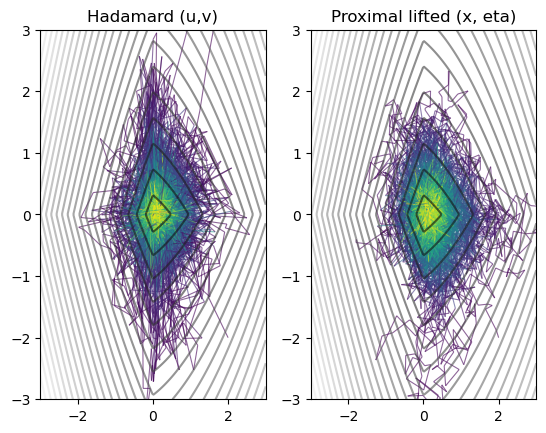

In [996]:
from scipy.stats import gaussian_kde
from matplotlib.collections import LineCollection

plt.subplot(1, 2, 1)
plt.contour(xx, yy, -Z, levels=30, cmap='gray_r',  zorder=2, alpha=.6)

# Color line by local visit density
xy = traj_hadam.T  # shape (2, n)
density = gaussian_kde(xy)(xy)

points = traj_hadam.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', linewidth=0.8, zorder=1,alpha=0.6)
lc.set_array(density)

plt.gca().add_collection(lc)

plt.title("Hadamard (u,v)")
# plt.show()


# Gibbs
plt.subplot(1,2,2)
plt.contour(xx, yy, -Z, levels=30, cmap='gray_r', zorder=2, alpha=.6)

# Color line by local visit density
xy = traj_prox.T  # shape (2, n)
density = gaussian_kde(xy)(xy)

points = traj_prox.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', linewidth=0.8, zorder=1,alpha=0.6)
lc.set_array(density)
plt.gca().add_collection(lc)

plt.title("Proximal lifted (x, eta)")
plt.show()

# Visualize (u,v) or (x,eta) for case $d=1$

In [848]:
from scipy.stats import invgauss

def sample_eta_given_x(x, lam, beta):
    eta = np.zeros_like(x)
    for j in range(len(x)):
        mu = abs(1./(beta*lam*np.abs(x[j]) + 1e-8))  # avoid division by 0
        eta[j] = 1 / invgauss.rvs(mu=mu, scale=(lam*beta)**2)
    return eta

def hadamard_to_x_eta(z, p, beta):
    u = z[:p]
    v = z[p:]
    x = u * v
    eta = (u**2) / beta / lam  
    return x, eta

In [966]:
import matplotlib.pyplot as plt

p = 1
lam = .8
beta= 2

gamma= 1/6
tau = gamma/5/(gamma+1)

# smooth part: G(x) = 1/2 ||x||^2
grad = lambda x: 2*(x-2)
def fval(x):
    return  (x-2)**2


# initial points
x0 = np.array([-1.0])
z0 = np.concatenate([np.ones(p), x0])  # (u,v)

# kernels
prox_step = make_prox_kernel(tau, grad, lam, gamma, p)
had_step = make_hadamard_kernel(tau, grad, lam, p)



In [967]:
#generate trajectories
T = 3000
# store trajectories
traj_uv = []
traj_x_eta = []
traj_x_eta_hadam = []

x = x0.copy()
z = z0.copy()

for _ in range(T):
    # proximal step
    x = prox_step(x)
    eta = sample_eta_given_x(x, lam, beta)

    # hadamard step
    z = had_step(z)
    u, v = z[:p], z[p:]

    #convert hadamard to x,eta
    x_uv, eta_uv = hadamard_to_x_eta(z, p, beta)
    traj_x_eta_hadam.append([x_uv[0], eta_uv[0]])

    # store only first coordinate (clean 2D plot)
    traj_uv.append([u[0], v[0]])
    traj_x_eta.append([x[0], eta[0]])

traj_uv = np.array(traj_uv)
traj_x_eta = np.array(traj_x_eta)
traj_x_eta_hadam = np.array(traj_x_eta_hadam)


In [968]:
# contours
uu, vv = np.meshgrid(np.linspace(0.001,3,200), np.linspace(-1.5,2.5,200))
X = uu * vv
Z_uv = beta*(fval(X)  +0.5* lam*uu**2 + 0.5* lam*vv**2) - np.log(uu)


xx, ee = np.meshgrid(np.linspace(-1,3,200), np.linspace(.00001,6,200))
Z_xe = beta*fval(xx) + 0.5*(xx**2 / ee) +0.5* lam**2*beta**2 * ee + np.log(np.sqrt(ee))

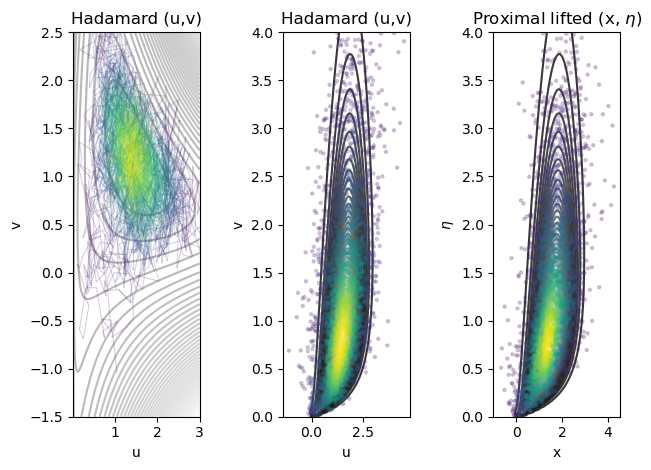

In [978]:
from scipy.stats import gaussian_kde
from matplotlib.collections import LineCollection

# 1. trajectories of u,v from hadamard-langevin

plt.subplot(1, 3, 1)
plt.contour(uu, vv, ( -Z_uv), levels=50, cmap='gray_r', alpha=0.3)

xy = traj_uv.T  # shape (2, n)
density = gaussian_kde(xy)(xy)
points = traj_uv.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', linewidth=0.8, zorder=2, alpha=.2)
lc.set_array(density)
plt.gca().add_collection(lc)
plt.xlabel("u")
plt.ylabel("v")
plt.title("Hadamard (u,v)")


# 2. scatter x-eta from hadamard-langevin
plt.subplot(1, 3, 2)
plt.contour(xx, ee, 1-np.exp(-Z_xe), levels=40, cmap='gray_r',  zorder=2, alpha=0.8)

xy = traj_x_eta_hadam.T  # shape (2, n)
density = gaussian_kde(xy)(xy)

plt.scatter(
    traj_x_eta_hadam[:,0],
    traj_x_eta_hadam[:,1],
    c=density,
    cmap='viridis',
    s=5,
    alpha=0.2,
    zorder=2
)

plt.title("Hadamard (u,v)")
plt.xlabel("u")
plt.ylabel("v")
plt.ylim([0,4])


# 3. scatter x-eta from prox-langevin
plt.subplot(1,3,3)

# background contour
plt.contour(xx, ee, 1-np.exp(-Z_xe), levels=40, cmap='gray_r', alpha=0.8)

# KDE density
xy = traj_x_eta.T  # shape (2, n)
density = gaussian_kde(xy)(xy)

# scatter with density coloring
plt.scatter(
    traj_x_eta[:,0],
    traj_x_eta[:,1],
    c=density,
    cmap='viridis',
    s=5,
    alpha=0.2,
    zorder=2
)

# plt.colorbar(label="density")
plt.title("Proximal lifted (x, $\eta$)")
plt.xlabel("x")
plt.ylabel("$\eta$")
plt.ylim([0,4])


plt.tight_layout(w_pad=2)

plt.show()
